### **TRABAJO PRÁCTICO N° 2: Redes Convolucionales, Detección de Objetos y Redes Recurrentes - Problema 2**
---
 1er cuatrimestre - Año 2026

| **Integrantes**           | **Legajo** |
|---------------------------|------------|
| Martinez Dufour, Caterina | M-7169/2   |
| Grimaldi, Damián Daniel   | G-5977/3   |
| Tapia, Fabrizio           | T-3095/3   |

**Docentes:** *Salvañá, Leandro* - *Fernández, Florencia*

### 1. Descripción del dataset
---

In [ ]:
# Librerías
import pandas as pd
import seaborn as sns
import yaml
import cv2
import pathlib
import gdown
import zipfile
import os
import random, numpy as np, torch
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

### 2. Carga del dataset
---

In [8]:
# ID de tu archivo de Drive
file_id = '1xiiGu2mN5KbKWM1_oRznQEL97hrkSGW_'
url = f'https://drive.google.com/uc?id={file_id}'
archivo_descargado = 'Traffic_Signs_Detection.zip' 

# Descargar el archivo
gdown.download(url, archivo_descargado, quiet=False)
# Descomprimir el archivo en la carpeta
carpeta_destino = 'dataset_problema2'

# Creamos la carpeta si no existe
if not os.path.exists(carpeta_destino):
    os.makedirs(carpeta_destino)

# Extraemos el contenido
try:
    with zipfile.ZipFile(archivo_descargado, 'r') as zip_ref:
        zip_ref.extractall(carpeta_destino)
    # Eliminar el archivo .zip descargado
    os.remove(archivo_descargado) 
    
except zipfile.BadZipFile:
    print("Error.")

Downloading...
From (original): https://drive.google.com/uc?id=1xiiGu2mN5KbKWM1_oRznQEL97hrkSGW_
From (redirected): https://drive.google.com/uc?id=1xiiGu2mN5KbKWM1_oRznQEL97hrkSGW_&confirm=t&uuid=966519c8-83ac-4a4c-a8ec-eed8e48e48d0
To: /content/Traffic_Signs_Detection.zip
100%|██████████| 105M/105M [00:01<00:00, 59.7MB/s] 


In [10]:
DATASET_2 = "dataset_problema2/car"
train = os.path.join(DATASET_2, 'train/images')
test = os.path.join(DATASET_2, 'test/images')
validation = os.path.join(DATASET_2, 'valid/images')

total = len(os.listdir(train)) + len(os.listdir(test)) + len(os.listdir(validation))

print(f"Train: {len(os.listdir(train))} ({len(os.listdir(train))/total*100:.2f}%)")
print(f"Test: {len(os.listdir(test))} ({len(os.listdir(test))/total*100:.2f}%)")
print(f"Validation: {len(os.listdir(validation))} ({len(os.listdir(validation))/total*100:.2f}%)")
print(f"Total: {total}")

#Tipos de señales de tráfico indicadas en el json
print("-------------")
with open(os.path.join(DATASET_2, 'data.yaml'), 'r') as f:
    data = yaml.safe_load(f)
    print("Clases:")
    print(data['names'])  



Train: 3530 (71.04%)
Test: 638 (12.84%)
Validation: 801 (16.12%)
Total: 4969
-------------
Clases:
['Green Light', 'Red Light', 'Speed Limit 10', 'Speed Limit 100', 'Speed Limit 110', 'Speed Limit 120', 'Speed Limit 20', 'Speed Limit 30', 'Speed Limit 40', 'Speed Limit 50', 'Speed Limit 60', 'Speed Limit 70', 'Speed Limit 80', 'Speed Limit 90', 'Stop']


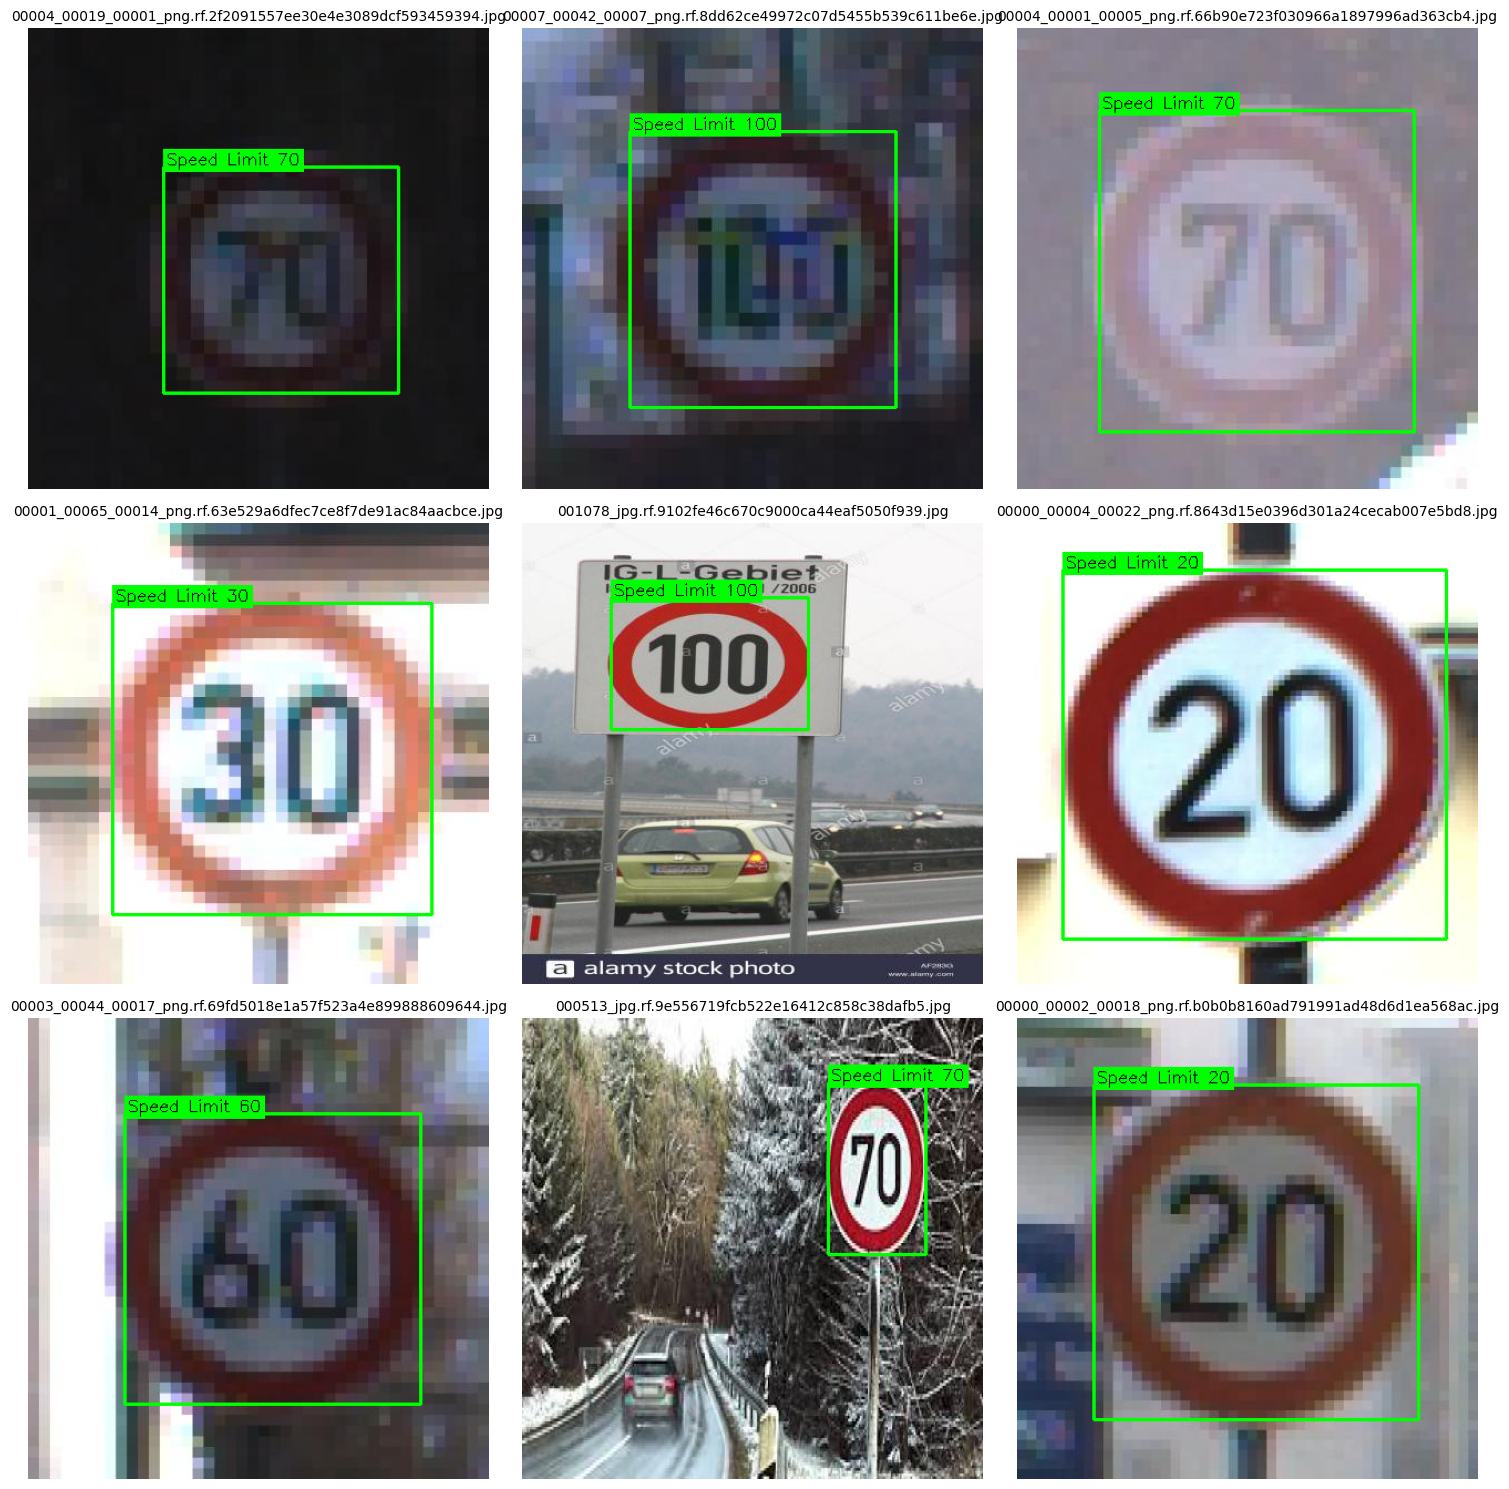

In [ ]:
names = [
    'Green Light', 'Red Light', 'Speed Limit 10', 'Speed Limit 100',
    'Speed Limit 110', 'Speed Limit 120', 'Speed Limit 20', 'Speed Limit 30',
    'Speed Limit 40', 'Speed Limit 50', 'Speed Limit 60', 'Speed Limit 70',
    'Speed Limit 80', 'Speed Limit 90', 'Stop'
]

def visualizar_anotacion(img_path, lbl_path, class_names):
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"Error: No se pudo cargar la imagen en {img_path}")
        return None
    
    h, w = img.shape[:2]
    
    colors = [
        (0, 255, 0), (0, 0, 255), (255, 0, 0), 
        (0, 255, 255), (255, 0, 255), (255, 255, 0)
    ]
    
    if not Path(lbl_path).exists():
        print(f"Advertencia: No existe archivo de etiquetas en {lbl_path}")
        return img
        
    with open(lbl_path) as f:
        for i, line in enumerate(f):
            parts = line.strip().split()
            if len(parts) < 5:
                continue
                
            cls, cx, cy, bw, bh = parts
            cls = int(cls)
            
            cx, cy, bw, bh = float(cx) * w, float(cy) * h, float(bw) * w, float(bh) * h
            
            x1 = int(cx - bw / 2)
            y1 = int(cy - bh / 2)
            x2 = int(cx + bw / 2)
            y2 = int(cy + bh / 2)
            
            color = colors[i % len(colors)]
            
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            
            label = class_names[cls]
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            ty1 = max(y1, th + 4)
            
            cv2.rectangle(img, (x1, ty1 - th - 4), (x1 + tw + 4, ty1 + 4), color, -1) # -1 rellena
            cv2.putText(img, label, (x1 + 2, ty1 - 2), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
            
    return img

# USO 
PATH_IMAGENES = Path("dataset_problema2/car/train/images")
PATH_LABELS = Path("dataset_problema2/car/train/labels")
todas_las_imagenes = list(PATH_IMAGENES.glob("*.jpg"))

CANTIDAD_A_MOSTRAR = 9
imagenes_muestra = todas_las_imagenes[:CANTIDAD_A_MOSTRAR]

if imagenes_muestra:
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.ravel() 
    
    for idx, img_path in enumerate(imagenes_muestra):
        lbl_path = PATH_LABELS / f"{img_path.stem}.txt"
        
        resultado_img = visualizar_anotacion(img_path, lbl_path, names)
        
        if resultado_img is not None:

            resultado_rgb = cv2.cvtColor(resultado_img, cv2.COLOR_BGR2RGB)
            
            axes[idx].imshow(resultado_rgb)
            axes[idx].set_title(img_path.name, fontsize=10)
            axes[idx].axis('off')
        else:
            axes[idx].axis('off') 
            
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron imágenes en la ruta especificada.")

### 3. Entrenamiento
---

In [ ]:


from ultralytics import YOLO
import os

RUTA_YAML = "dataset_problema2/car/data.yaml"

modelos_a_entrenar = {
    "nano": "yolov8n.pt",   # Nano: Liviano 
    "small": "yolov8s.pt"  # Small: Más pesado pero más preciso
}

# Parámetros de entrenamiento fijados por el enunciado y las recomendaciones
CONFIG_ENTRENAMIENTO = {
    "data": RUTA_YAML,
    "epochs": 50,       # del ejemplo
    "imgsz": 640,       # Tamaño de resolución estándar de las imágenes
    "project": "tp2_senales", #
    "device": 0         # 0 para GPU, o 'cpu'
}

# Bucle para entrenar ambos modelos de forma secuencial
for tamano, checkpoint_base in modelos_a_entrenar.items():
    print("\n" + "="*60)
    print(f"INICIANDO ENTRENAMIENTO DEL MODELO YOLOv8 ({tamano.upper()})")
    print("="*60 + "\n")
    
    # Inicializamos el modelo cargando los pesos preentrenados
    model = YOLO(checkpoint_base)
    
    # Lanzamos el entrenamiento asignándole un nombre de versión específico a cada uno
    results = model.train(
        name=f"yolov8_{tamano}_v1",
        **CONFIG_ENTRENAMIENTO
    )
    
    print(f"\n Entrenamiento de YOLOv8 {tamano} finalizado con éxito.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

INICIANDO ENTRENAMIENTO DEL MODELO YOLOv8 (NANO)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_problema2/car/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None

#### Análisis Cuantitativo del Entrenamiento (Nano vs. Small)

A partir de las métricas recopiladas al finalizar las 50 épocas en ambos tamaños de arquitectura, se realiza la siguiente comparación de rendimiento en el conjunto de validación:

##### Tabla Comparativa de Rendimiento General
| Modelo | Parámetros | mAP@50 | mAP@50-95 | Tiempo de Entrenamiento | Tiempo Inferencia (por img) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **YOLOv8 Nano** (`yolov8_nano_v1`) | 3,008,573 | 0.972 | 0.836 | 0.880 horas (~53 min) | **2.2 ms** |
| **YOLOv8 Small** (`yolov8_small_v1`) | 11,131,389 | **0.976** | **0.844** | 1.040 horas (~62 min) | 4.6 ms |

##### Comparativa del Comportamiento de las Curvas

1. **Convergencia y Evolución de Pérdidas:**
   * Ambos modelos iniciaron con un comportamiento regular y mostraron un descenso drástico en las curvas de pérdida de caja (`box_loss`) y clasificación (`cls_loss`) a partir de la época 41, momento en que el cargador de datos cierra la técnica de aumentación por mosaico (`Closing dataloader mosaic`).
   * Al cerrar el mosaico en la época 50, **YOLOv8 Small** logró minimizar la pérdida de clasificación (`cls_loss: 0.2622`) en una escala notablemente menor que **YOLOv8 Nano** (`cls_loss: 0.3248`), demostrando que su mayor volumen de parámetros le permite refinar mejor los rasgos geométricos de las señales de tráfico.

2. **Rendimiento por Categoría de Señal (mAP@50-95):**
   * **Señales de Luces (Green/Red Light):** Fueron las categorías más desafiantes para ambas redes. Sin embargo, el modelo **Small** pegó un salto de calidad rotundo en `Green Light`, escalando el mAP de **0.882 (Nano)** a **0.924 (Small)**. Esto corrobora que las capas adicionales procesan con mayor éxito los objetos texturizados pequeños en entornos viales complejos.
   * **Límites de Velocidad e Indicadores Estructurales:** Las señales numéricas (`Speed Limit 100` a `120`) e imperativas (`Stop`) rozaron la perfección en ambas arquitecturas (métricas sobre 0.985), evidenciando que el dataset provee características lo suficientemente legibles para que incluso una red compacta como la Nano logre generalizar sin dificultades.

3. **Conclusión del Trade-off (Velocidad vs. Precisión):**
   * El incremento en la complejidad del modelo **Small** (triplica la cantidad de parámetros del Nano) representó solo un **18% más de tiempo de entrenamiento** corriendo sobre la GPU Tesla T4.
   * En términos de inferencia en producción, **YOLOv8 Nano es el doble de rápido (2.2 ms vs 4.6 ms)**. Sin embargo, dado que ambos tiempos se sitúan muy por debajo del umbral estándar para procesamiento en tiempo real (30 FPS $\approx$ 33 ms), el incremento en la precisión general (`mAP@50-95` de **0.844**) y el notable rescate de las clases complejas justifican plenamente la adopción del modelo **Small** para esta aplicación específica.

### 4. Reportes 
---

#### Curvas de aprendizaje y métricas de evaluación del modelo NANO

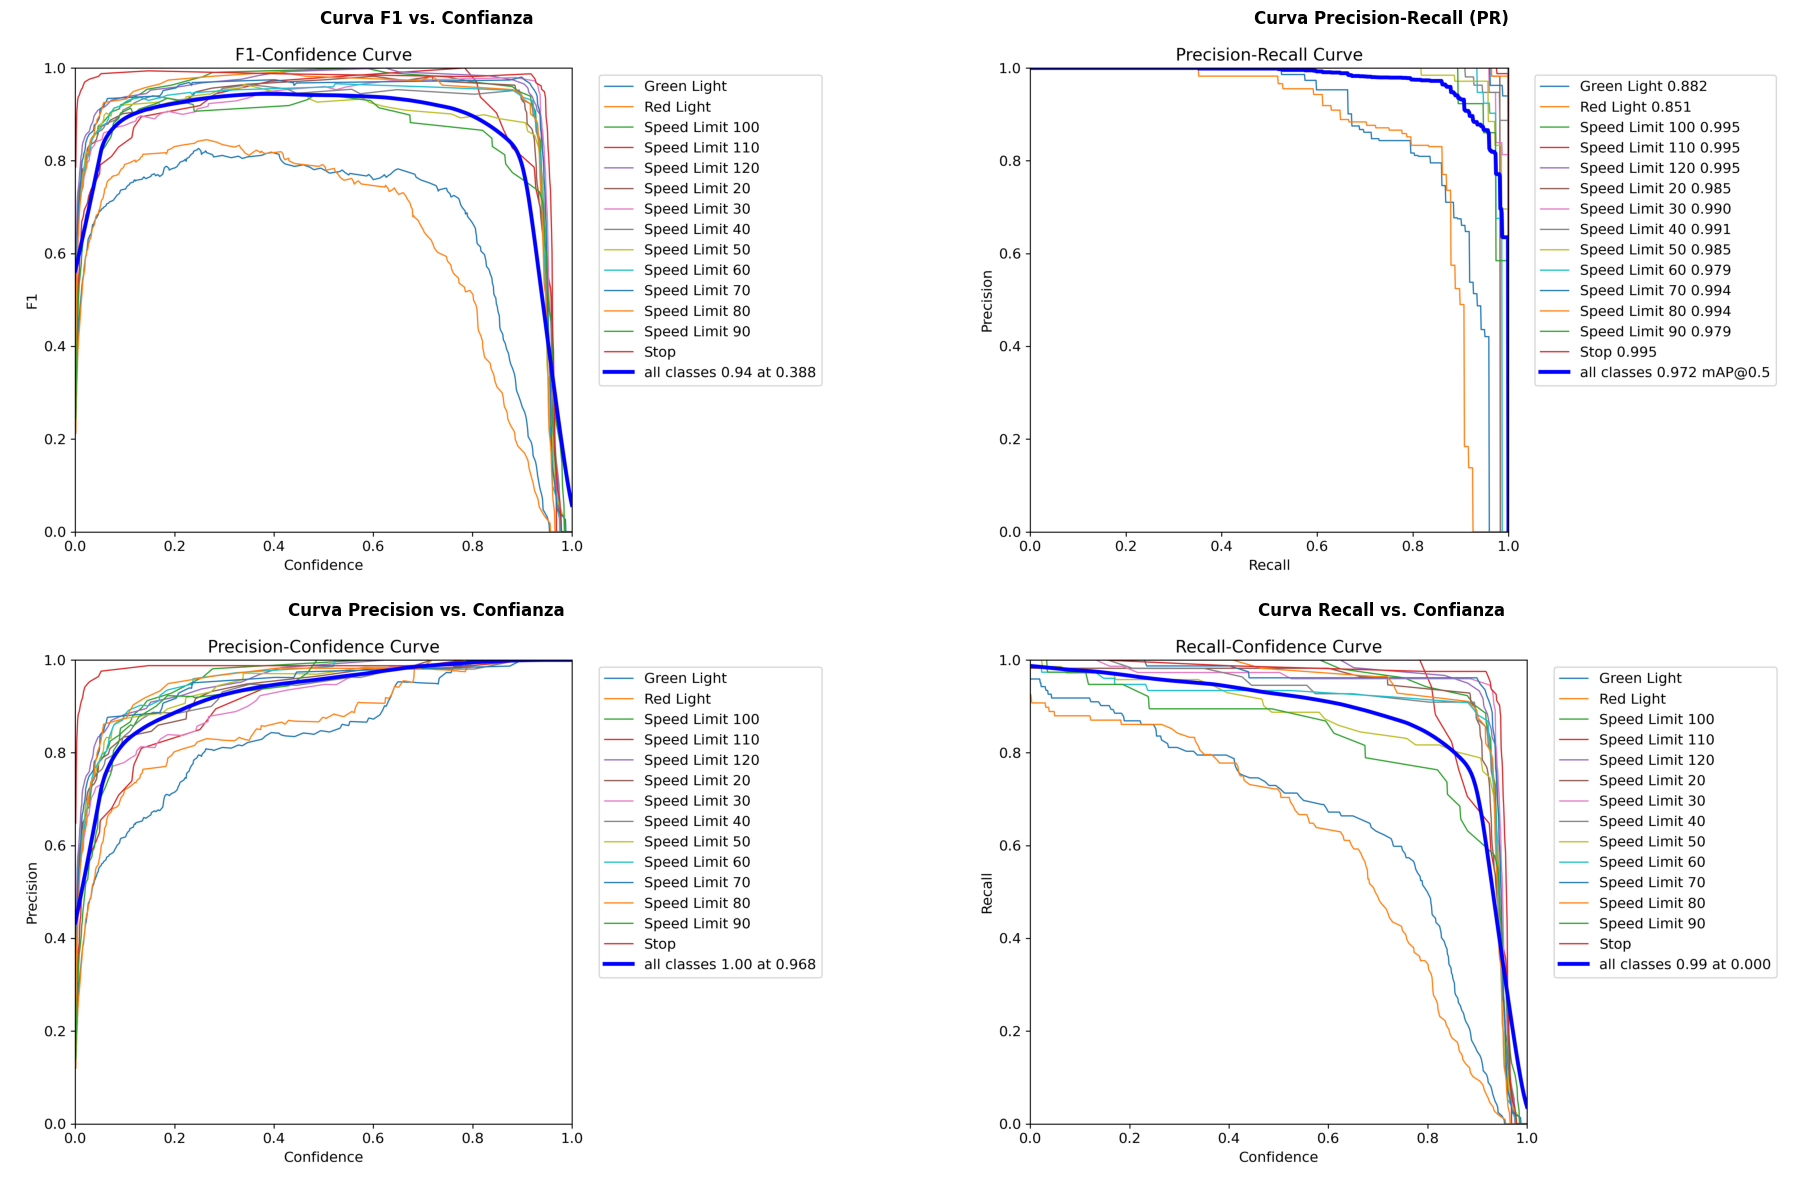

In [19]:
PATH_MODELO = Path("yolov8_nano_v1") 
archivos_curvas = [
    {"archivo": "BoxF1_curve.png", "titulo": "Curva F1 vs. Confianza"},
    {"archivo": "BoxPR_curve.png", "titulo": "Curva Precision-Recall (PR)"},
    {"archivo": "BoxP_curve.png", "titulo": "Curva Precision vs. Confianza"},
    {"archivo": "BoxR_curve.png", "titulo": "Curva Recall vs. Confianza"}
]

if not PATH_MODELO.exists():
    print(f"Error: No se encuentra la carpeta {PATH_MODELO}")
else:
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    axes = axes.ravel() 
    
    for idx, item in enumerate(archivos_curvas):
        img_path = PATH_MODELO / item["archivo"]
        
        if img_path.exists():
            
            img_bgr = cv2.imread(str(img_path))
            
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

            axes[idx].imshow(img_rgb)
            axes[idx].set_title(item["titulo"], fontsize=12, fontweight='bold')
            axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, f"No se encontró\n{item['archivo']}", 
                           ha='center', va='center', fontsize=10, color='red')
            axes[idx].axis('off')
                
    plt.tight_layout()
    plt.show()

**Análisis de las Curvas de Rendimiento (Métricas vs. Confianza)**


1. **Curva F1 vs. Confianza (F1-Confidence Curve):**
   * El gráfico muestra el balance armónico entre la Precisión y el Recall. El rendimiento global alcanza su punto máximo (`all classes`) con un **F1-Score de 0.94 a un umbral de confianza óptimo de 0.388**.
   * **Interpretación práctica:** Configurar el modelo con un *confidence threshold* de aproximadamente **0.39** en producción garantizará la mejor relación entre señales correctamente detectadas y la reducción de falsos positivos. Las curvas más caídas corresponden a `Red Light` y `Green Light`, confirmando que son las clases que más penalizan el rendimiento general.

2. **Curva Precision-Recall (PR_curve):**
   * El modelo demuestra una solidez notable, alcanzando un **mAP@0.5 de 0.972** promediando todas las clases.
   * La curva se mantiene cercana a la esquina superior derecha (área bajo la curva muy próxima a 1.0) para casi todas las señales de límites de velocidad y la señal de `Stop` (que lidera con 0.995). La degradación del área se concentra principalmente en `Red Light` (0.851) y `Green Light` (0.882), arrastradas por dificultades de detección bajo ciertas condiciones de iluminación o escala.

3. **Curvas individuales de Precision y Recall vs. Confianza:**
   * **Precision vs. Confianza:** A medida que se exige mayor umbral de confianza al modelo, la precisión aumenta de forma drástica, llegando a un valor perfecto de **1.00 a un umbral de 0.968**. Esto significa que si configuramos el filtro muy alto, el modelo casi no cometerá falsos positivos (las detecciones que haga serán 100% reales), a costa de perder objetos.
   * **Recall vs. Confianza:** Se observa el efecto inverso complementario. Con confianza en cero, el modelo encuentra el **99% de los positivos reales (`0.99 at 0.000`)**. Sin embargo, a medida que el umbral de confianza sube hacia el valor óptimo de 0.388, el recall general se mantiene alto (alrededor del 90%), cayendo abruptamente recién después de superar el umbral de 0.8. Esto demuestra la estabilidad de la red para retener detecciones verdaderas incluso con filtros de confianza moderados.

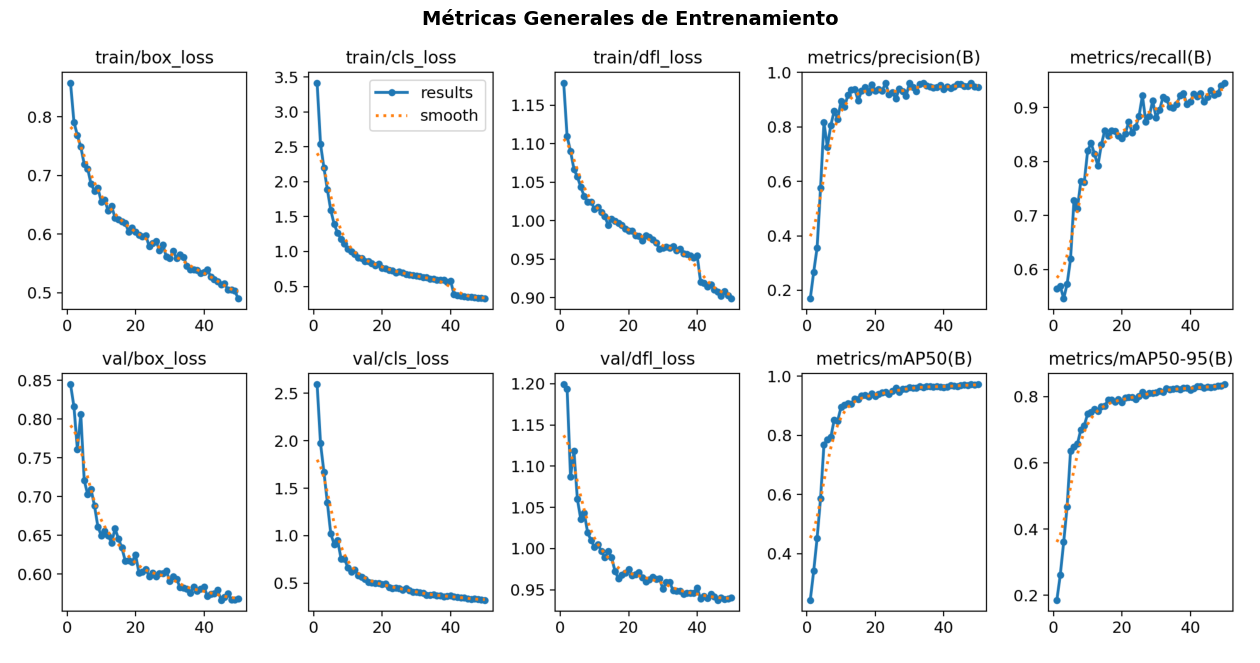

In [ ]:
if PATH_MODELO.exists():
    img_bgr = cv2.imread(str(PATH_MODELO / "results.png"))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(16, 10))
    plt.imshow(img_rgb)
    plt.title(f"Métricas Generales de Entrenamiento", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()
else:
    print("No se encontró el archivo")

**Análisis del Dashboard de Métricas Generales (`results.png`)**

1. **Evolución de las Pérdidas (Losses):**
   * **Pérdida de Caja (`box_loss`):** Muestra un descenso constante tanto en entrenamiento (`train`) como en validación (`val`), estabilizándose en la validación cerca de **0.57**. Esto indica que el modelo aprendió correctamente a ajustar y localizar las bounding boxes alrededor de las señales de tránsito.
   * **Pérdida de Clasificación (`cls_loss`):** Exhibe una caída drástica en las primeras 15 épocas. Se observa un escalón de descenso abrupto y definitivo en la **época 41** (momento exacto en que se desactiva la aumentación por mosaico), logrando estabilizar la pérdida de validación en un valor óptimo cercano a **0.30**.
   * **Pérdida de Distribución Focal (`dfl_loss`):** Sigue la misma tendencia descendente y regular, lo que valida que el modelo ganó precisión al refinar los bordes finos de los objetos.

2. **Diagnóstico de Overfitting (Sobreajuste):**
   * Al comparar de forma directa las curvas de `train` con las de `val` (especialmente en `box_loss` y `cls_loss`), se observa que las métricas de validación acompañan en todo momento la caída de las de entrenamiento sin sufrir rebotes o bifurcaciones alcistas hacia las épocas finales. Esto demuestra que **el modelo generaliza correctamente** y que no sufrió problemas de sobreajuste.

3. **Métricas de Rendimiento General:**
   * Las curvas de **Precisión** y **Recall** trepan rápidamente durante las primeras 10 épocas, estabilizándose por encima del **90%** hacia el final del proceso.
   * Los indicadores de **mAP50** y **mAP50-95** consolidan una curva de crecimiento impecable. El mAP50 se estabiliza de forma muy temprana (alrededor de la época 20) por encima del **95%**, mientras que la métrica más exigente (`mAP50-95`) continúa refinándose gradualmente a lo largo de las 50 épocas hasta consolidar su valor final superior al **83%**.

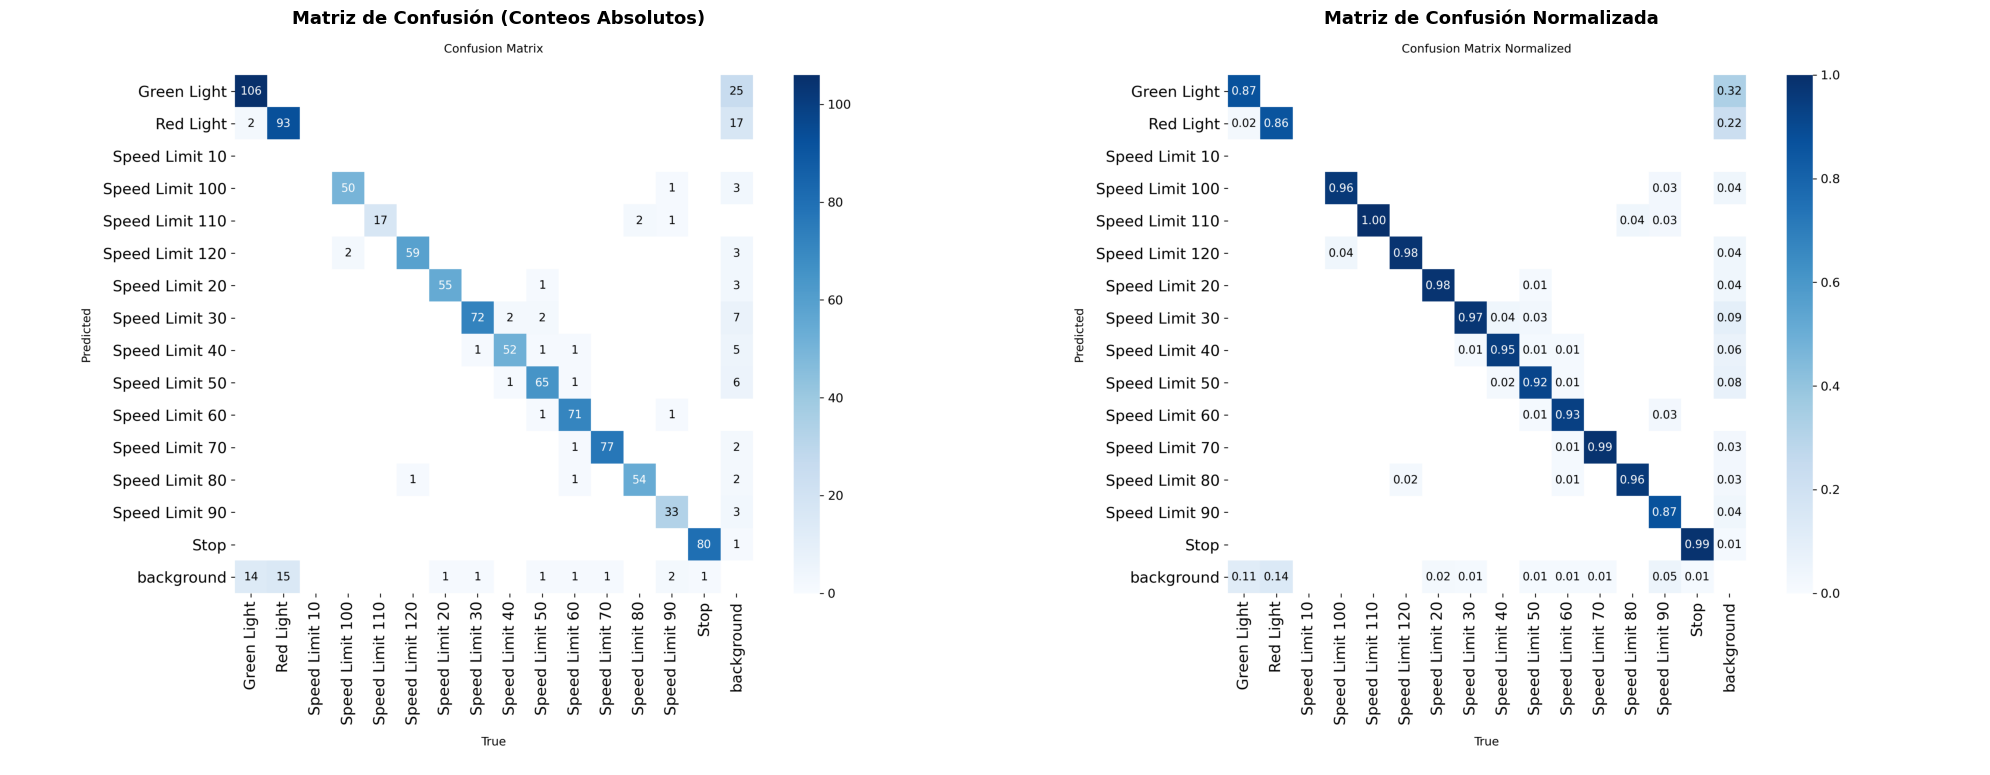

In [ ]:
matrices = [
    {"archivo": "confusion_matrix.png", "titulo": "Matriz de Confusión (Conteos Absolutos)"},
    {"archivo": "confusion_matrix_normalized.png", "titulo": "Matriz de Confusión Normalizada"}
]

if not PATH_MODELO.exists():
    print("Error: No se encuentra la carpeta")
else:
    

    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    for idx, item in enumerate(matrices):
        img_path = PATH_MODELO / item["archivo"]
        
        if img_path.exists():
            img_bgr = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            
            axes[idx].imshow(img_rgb)
            axes[idx].set_title(item["titulo"], fontsize=13, fontweight='bold')
            axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, f"No se encontró\n{item['archivo']}", 
                           ha='center', va='center', fontsize=12, color='red')
            axes[idx].axis('off')
            
    plt.tight_layout()
    plt.show()

**Análisis de las Matrices de Confusión**

1. **Clases con mejor rendimiento (La diagonal principal):**
   * Las señales de **Speed Limit 110**, **Speed Limit 70** y **Stop** alcanzan casi la perfección con un **1.00**, **0.99** y **0.99** de efectividad. 
   * En general, todos los límites de velocidad numéricos se detectan muy bien (valores por encima del **0.92**), lo que demuestra que el modelo diferencia bien los números dentro del círculo rojo.

2. **Confusiones con el Fondo (Falsos Negativos / Background):**
   * El error más repetido ocurre cuando el modelo no ve una señal y la confunde con el fondo de la imagen (`background`). 
   * Esto afecta principalmente a **Green Light** (un **0.32** se pierde con el fondo) y a **Red Light** (un **0.22** se pierde con el fondo). Al ser objetos más chicos o integrados en estructuras urbanas complejas, a la red le cuesta más separarlos del entorno.

3. **Confusiones entre Clases Similares:**
   * Existe una confusión lógica pero baja entre velocidades parecidas: por ejemplo, un **4%** de las señales de `Speed Limit 40` se confunden con `Speed Limit 30`, y un **5%** de `Speed Limit 90` se confunde con `Speed Limit 80`. Esto se debe a la similitud gráfica entre los caracteres (como el 3 y el 4, o el 8 y el 9).
   * También hay falsos positivos leves en el fondo (`background` real que el modelo confunde con luces rojas o verdes), sumando un **14%** y **11%** respectivamente.

#### Curvas de aprendizaje y métricas de evaluación del modelo SMALL

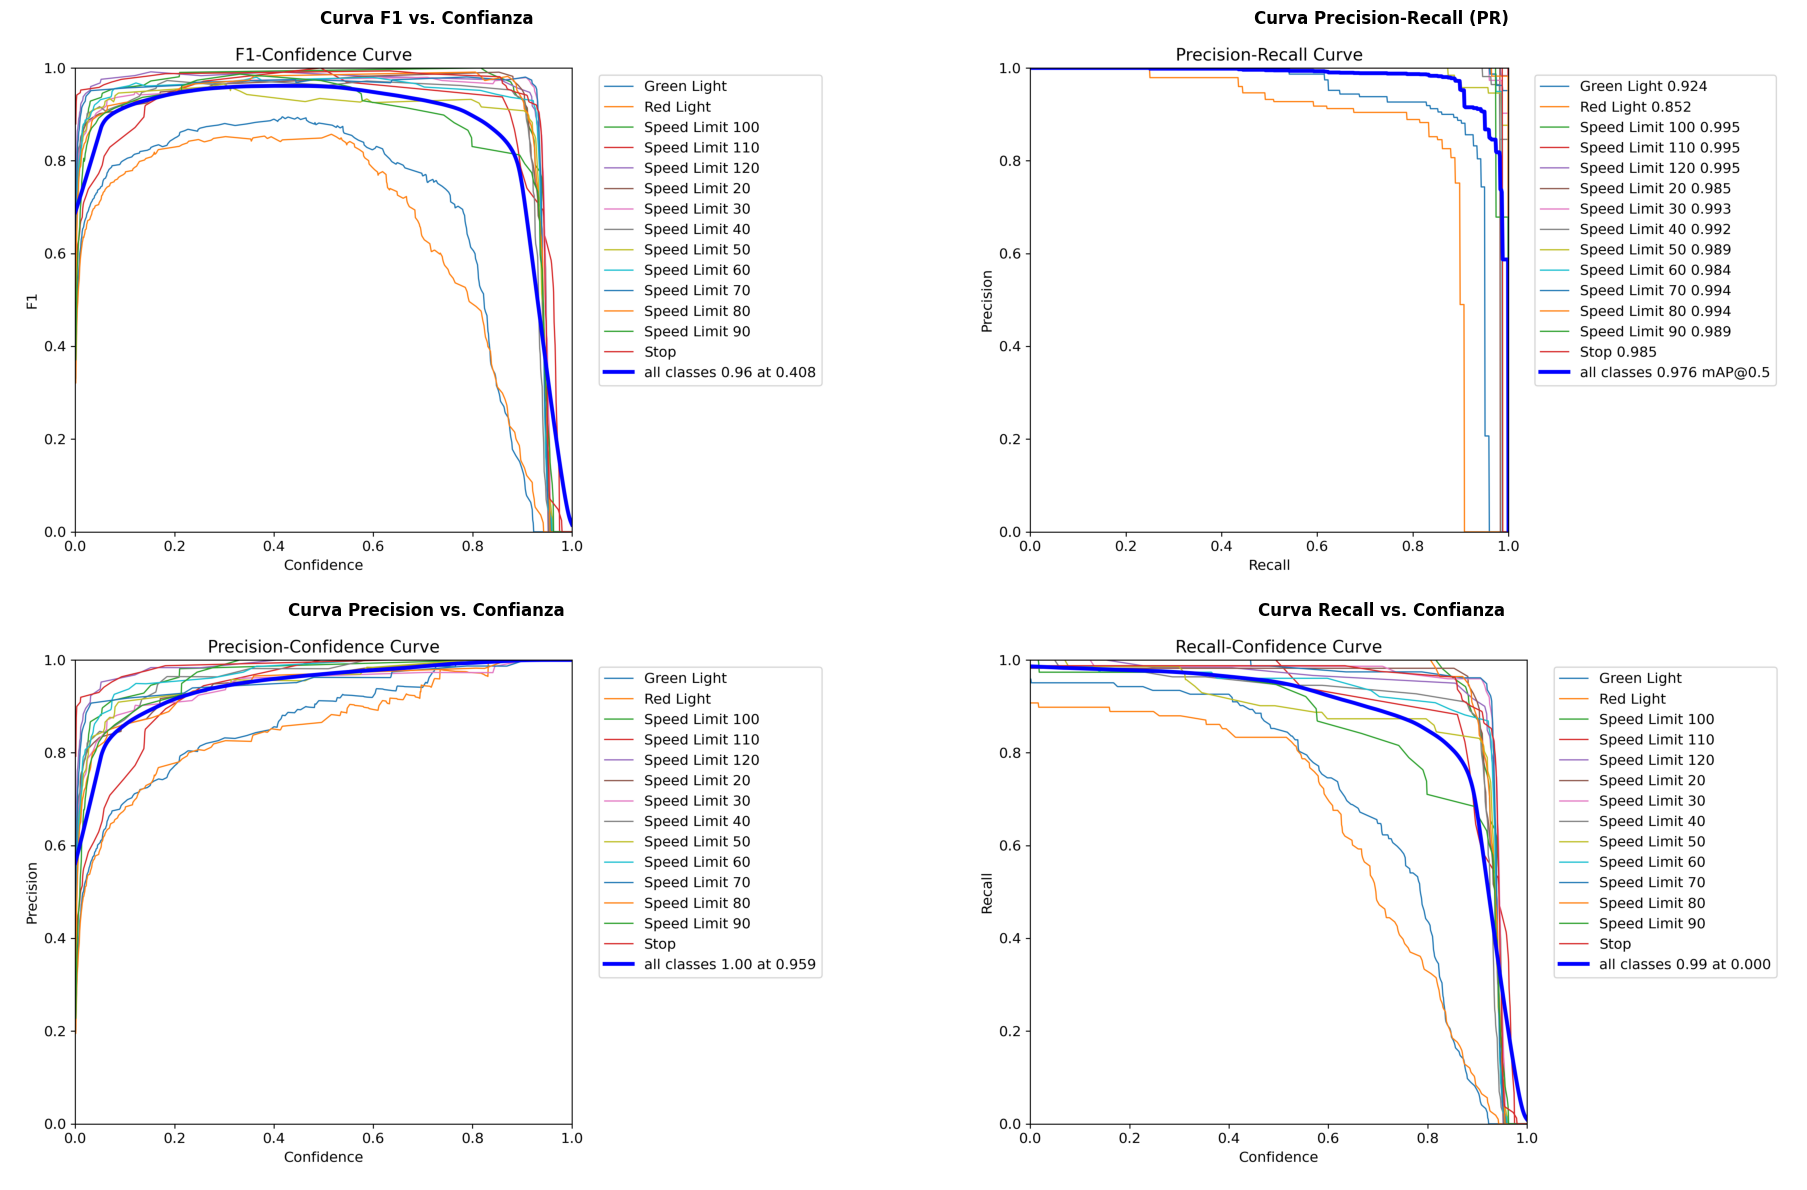

In [ ]:
PATH_MODELO_SMALL = Path("yolov8_small_v1") 
archivos_curvas = [
    {"archivo": "BoxF1_curve.png", "titulo": "Curva F1 vs. Confianza"},
    {"archivo": "BoxPR_curve.png", "titulo": "Curva Precision-Recall (PR)"},
    {"archivo": "BoxP_curve.png", "titulo": "Curva Precision vs. Confianza"},
    {"archivo": "BoxR_curve.png", "titulo": "Curva Recall vs. Confianza"}
]

if not PATH_MODELO_SMALL.exists():
    print("Error: No se encuentra la carpeta")
else:
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    axes = axes.ravel() 
    
    for idx, item in enumerate(archivos_curvas):
        img_path = PATH_MODELO_SMALL / item["archivo"]
        
        if img_path.exists():
            
            img_bgr = cv2.imread(str(img_path))
            
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

            axes[idx].imshow(img_rgb)
            axes[idx].set_title(item["titulo"], fontsize=12, fontweight='bold')
            axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, f"No se encontró\n{item['archivo']}", 
                           ha='center', va='center', fontsize=10, color='red')
            axes[idx].axis('off')
                
    plt.tight_layout()

**Análisis de las Curvas de Rendimiento**

1. **Curva F1 vs. Confianza (F1-Confidence Curve):**
   * El punto de equilibrio óptimo (`all classes`) se alcanza con un **F1-Score de 0.96 a un umbral de confianza de 0.408**.
   * **Interpretación práctica:** Al ser una red más robusta, el umbral operativo óptimo sube levemente a **0.41** (frente al 0.39 del Nano), logrando un rendimiento general superior y más seguro antes de empezar a perder detecciones.

2. **Curva Precision-Recall (PR_curve):**
   * El modelo consolida un **mAP@0.5 general de 0.976**.
   * La mejora más importante se ve en la clase más difícil, **Green Light**, que sube su mAP individual a **0.924** (en el Nano era de 0.882). Esto confirma que las capas extra del modelo Small ayudan a procesar mejor los objetos pequeños y complejos.

3. **Curvas de Precision y Recall vs. Confianza:**
   * **Precision vs. Confianza:** Se estabiliza de forma más limpia en la parte superior. Alcanza la precisión perfecta de **1.00 a un umbral de 0.959**. Es un modelo más seguro que comete menos errores a umbrales altos.
   * **Recall vs. Confianza:** Parte con el mismo valor inicial (**0.99 a 0.000**), la curva azul (`all classes`) se mantiene "inflada" y plana hacia la derecha. Esto significa que a medida que subimos la exigencia de confianza, el modelo Small es capaz de retener muchas más señales verdaderas antes de que la curva empiece a caer.

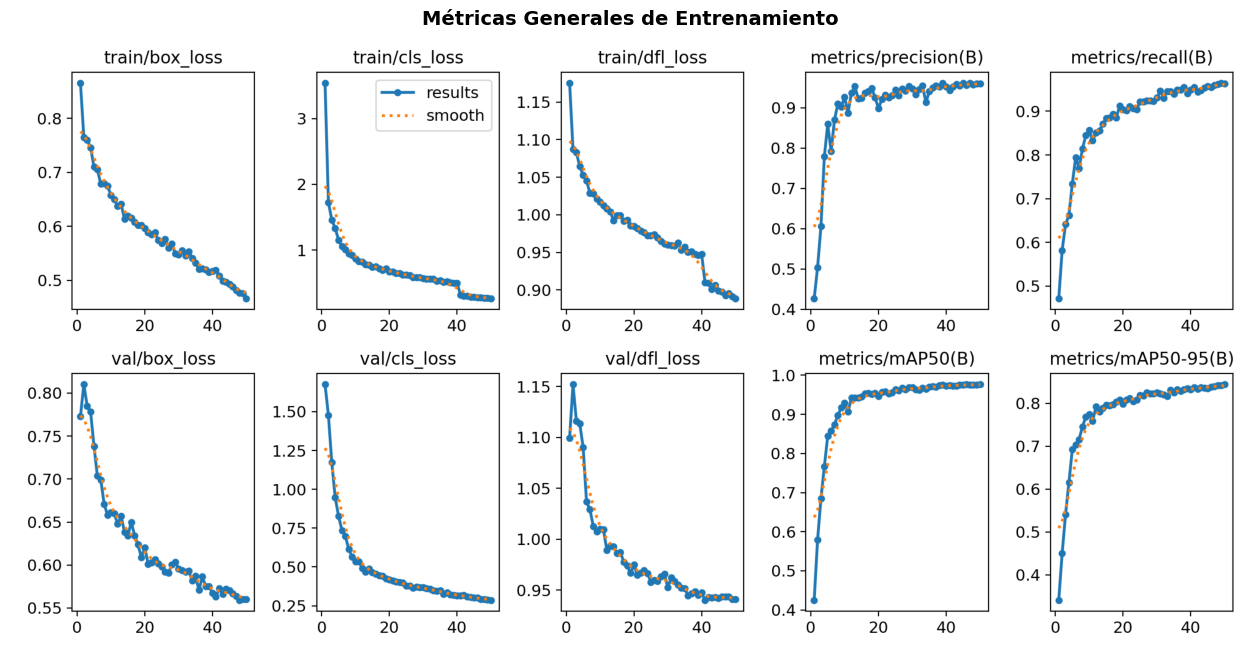

In [28]:
if PATH_MODELO_SMALL.exists():
    img_bgr = cv2.imread(str(PATH_MODELO_SMALL / "results.png"))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(16, 10))
    plt.imshow(img_rgb)
    plt.title(f"Métricas Generales de Entrenamiento", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()
else:
    print("No se encontró el archivo")

**Análisis del Dashboard de Métricas Generales**

1. **Optimización de las Pérdidas (Losses):**
   * **Pérdida de Caja (`box_loss`):** En validación baja de forma limpia y se estabiliza cerca de **0.55** hacia la época 50. Logra encuadrar las bounding boxes de manera más ajustada que el modelo Nano.
   * **Pérdida de Clasificación (`cls_loss`):** Es el punto más fuerte. En validación cae de forma continua y suave hasta tocar un valor óptimo de **0.25**. Esto demuestra que el modelo Small tiene menos dudas al etiquetar qué señal es cada cuál.
   * En la **época 41** se nota el clásico escalón hacia abajo en las pérdidas de entrenamiento (`train`), que es cuando el sistema desactiva el mosaico de imágenes para darle el refinamiento final al modelo.

2. **Diagnóstico de Salud del Entrenamiento:**
   * Al igual que el Nano, este entrenamiento es sumamente sano: **no hay ningún síntoma de overfitting (sobreajuste)**. Las líneas de validación (`val`) bajan a la par de las de entrenamiento (`train`) en todo momento, confirmando que lo que aprende en el laboratorio lo sabe aplicar bien en datos nuevos.

3. **Métricas de Precisión Finales:**
   * Las curvas de **mAP50** y **mAP50-95** muestran un crecimiento muy firme y con menos oscilaciones que el modelo Nano. 
   * La métrica más estricta (`mAP50-95`) se consolida por encima del **84% (0.844)** en validación, coronando un entrenamiento muy estable y preciso.

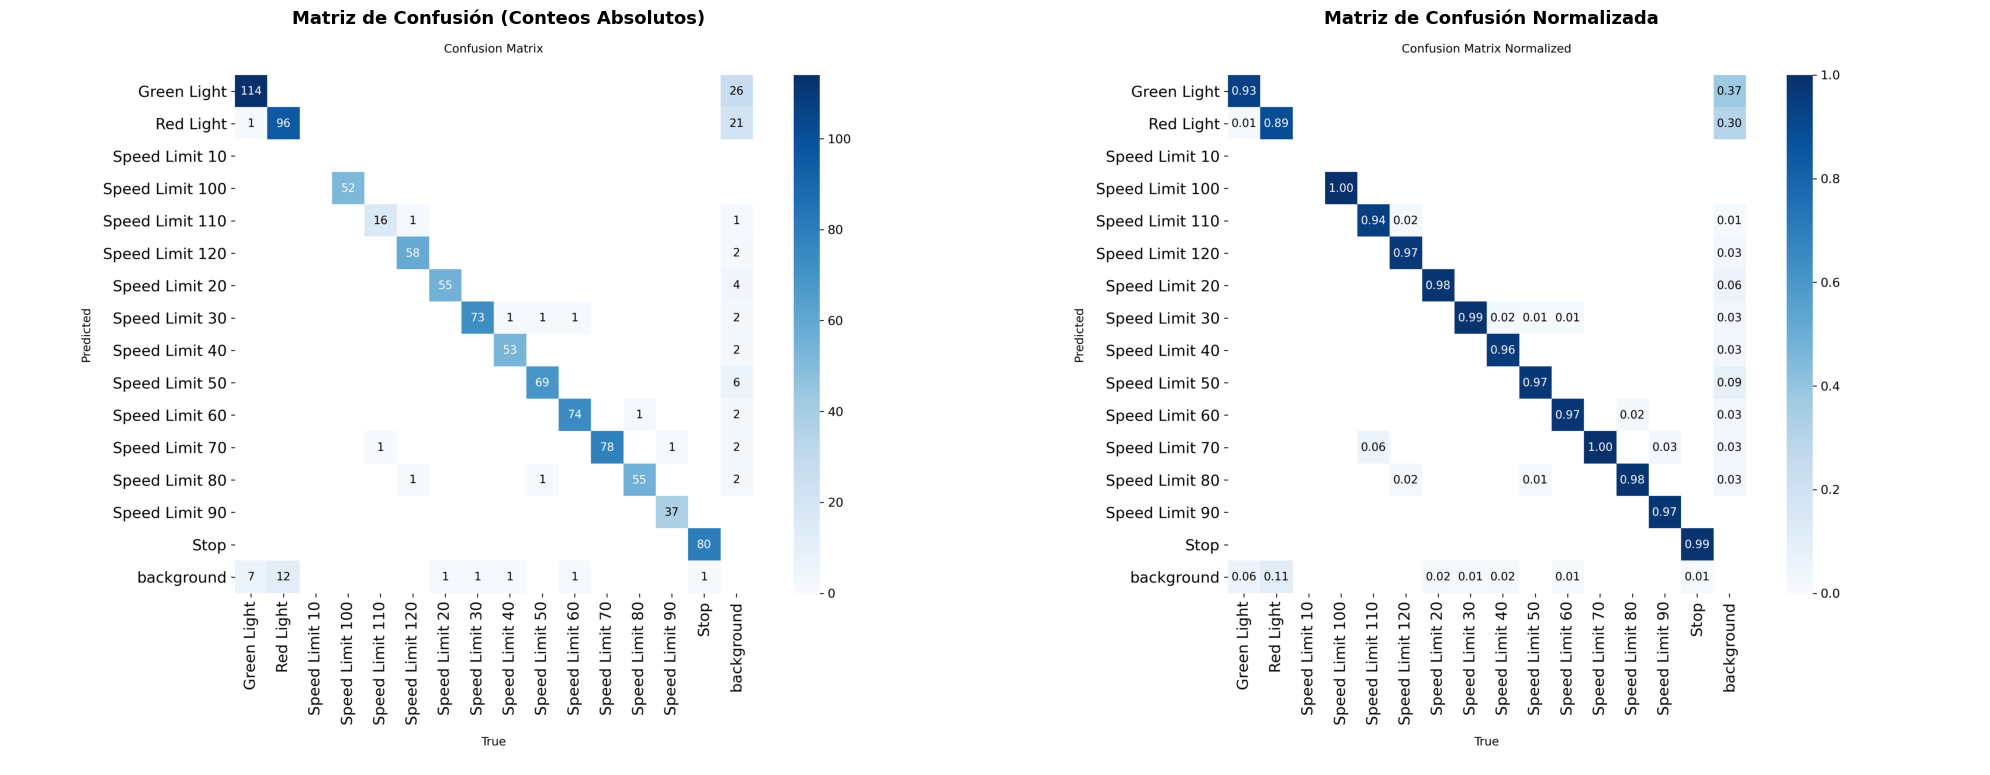

In [29]:
matrices = [
    {"archivo": "confusion_matrix.png", "titulo": "Matriz de Confusión (Conteos Absolutos)"},
    {"archivo": "confusion_matrix_normalized.png", "titulo": "Matriz de Confusión Normalizada"}
]

if not PATH_MODELO_SMALL.exists():
    print("Error: No se encuentra la carpeta")
else:
    

    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    for idx, item in enumerate(matrices):
        img_path = PATH_MODELO_SMALL / item["archivo"]
        
        if img_path.exists():
            img_bgr = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            
            axes[idx].imshow(img_rgb)
            axes[idx].set_title(item["titulo"], fontsize=13, fontweight='bold')
            axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, f"No se encontró\n{item['archivo']}", 
                           ha='center', va='center', fontsize=12, color='red')
            axes[idx].axis('off')
            
    plt.tight_layout()
    plt.show()

**Análisis de las Matrices de Confusión**

1. **Efectividad en la Diagonal Principal:**
   * El modelo Small muestra una precisión impresionante: las clases **Speed Limit 100**, **Speed Limit 70** y **Stop** alcanzan puntuaciones casi perfectas de **1.00**, **1.00** y **0.99**.
   * Prácticamente todos los límites de velocidad se consolidan por encima del **0.96** de aciertos, lo que demuestra la madurez del modelo para reconocer los caracteres numéricos internos.

2. **Mitigación de Errores con las Luces de Tránsito:**
   * La mejora más rotunda respecto al Nano se da en la detección de **Green Light** y **Red Light**.
   * El acierto de `Green Light` sube al **0.93** (frente al 0.87 del Nano) y el de `Red Light` sube al **0.89** (frente al 0.86 del Nano). Las capas extra de la arquitectura Small lograron rescatar gran parte de estas señales que antes se perdían.

3. **Confusiones Residuales:**
   * A pesar de las mejoras, el error principal sigue siendo el fondo (`background`). Un **0.37** de las luces verdes y un **0.30** de las luces rojas se siguen ignorando o confundiendo con el entorno urbano, aunque en menor medida que en el modelo Nano.
   * Las confusiones entre números similares (como confundir un límite de 40 con uno de 30) se redujeron a valores casi insignificantes (apenas un 2%), consolidando un sistema mucho más seguro.

#### Predicciones Modelo Nano

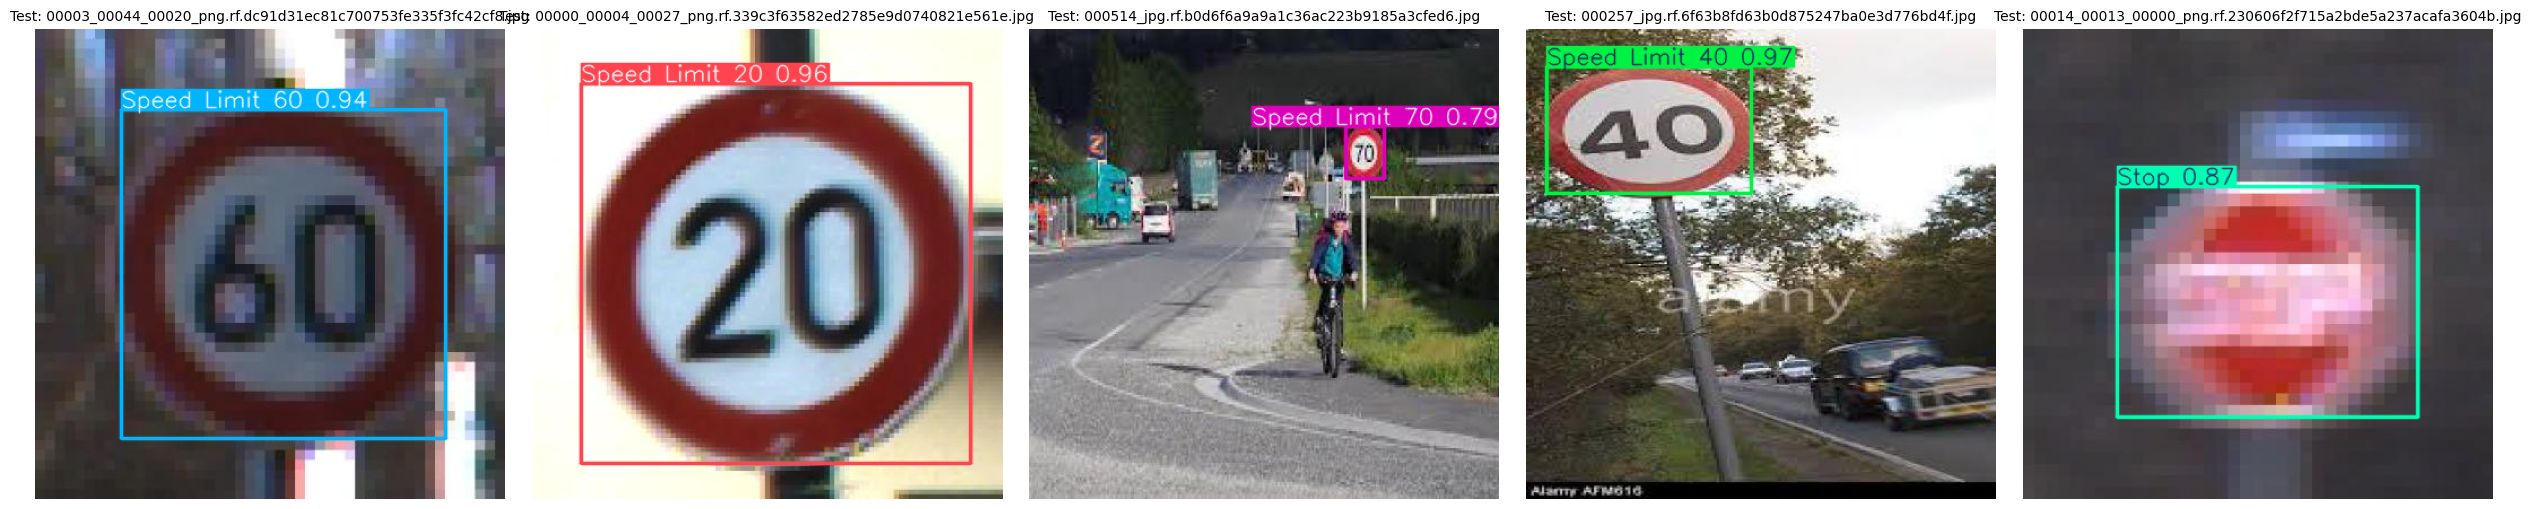

In [ ]:

PATH_MODELO = Path("yolov8_nano_v1/weights/best.pt") 

if not PATH_MODELO.exists():
    print(f"Error: No se encontró el archivo de pesos en {PATH_MODELO}")
else:
    model = YOLO(PATH_MODELO)
    
    PATH_TEST_IMAGES = Path("dataset_problema2/car/test/images")
    
    imagenes_test = list(PATH_TEST_IMAGES.glob("*.jpg")) 
    
    if len(imagenes_test) == 0:
        print("No se encontraron imágenes en la carpeta de test especificada.")
    else:
      
        random.seed(42) # Semilla para reproducibilidad del reporte
        muestras_test = random.sample(imagenes_test, min(5, len(imagenes_test)))
        
        fig, axes = plt.subplots(1, 5, figsize=(25, 5))
        if len(muestras_test) == 1:
            axes = [axes]  
            
        for idx, img_path in enumerate(muestras_test):
      
            results = model.predict(source=str(img_path), conf=0.25, verbose=False)
            
            img_predicha_bgr = results[0].plot()
            
            
            img_predicha_rgb = cv2.cvtColor(img_predicha_bgr, cv2.COLOR_BGR2RGB)
            
            axes[idx].imshow(img_predicha_rgb)
            axes[idx].set_title(f"Test: {img_path.name}", fontsize=10)
            axes[idx].axis('off')
            
        plt.tight_layout()
        plt.show()

#### Predicciones Modelo Small

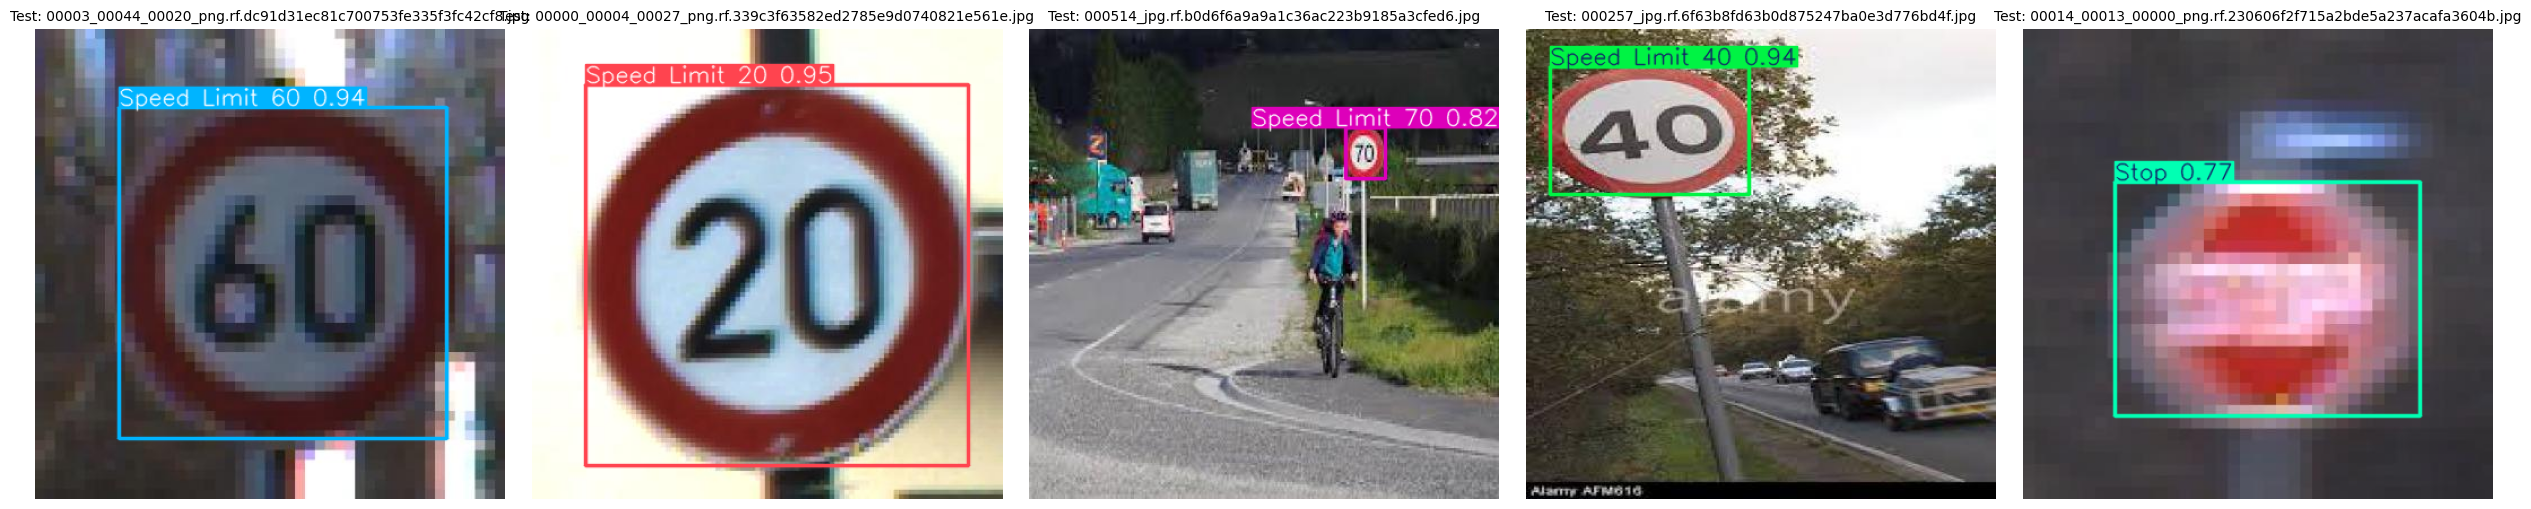

In [ ]:
PATH_MODELO = Path("yolov8_small_v1/weights/best.pt") 

if not PATH_MODELO.exists():
    print(f"Error: No se encontró el archivo de pesos en {PATH_MODELO}")
else:
    model = YOLO(PATH_MODELO)
    

    PATH_TEST_IMAGES = Path("dataset_problema2/car/test/images")
    
    imagenes_test = list(PATH_TEST_IMAGES.glob("*.jpg")) 
    
    if len(imagenes_test) == 0:
        print("No se encontraron imágenes en la carpeta de test especificada.")
    else:
        random.seed(42) # Semilla para reproducibilidad del reporte
        muestras_test = random.sample(imagenes_test, min(5, len(imagenes_test)))
       
        fig, axes = plt.subplots(1, 5, figsize=(25, 5))
        if len(muestras_test) == 1:
            axes = [axes]  
            
        for idx, img_path in enumerate(muestras_test):
         
            results = model.predict(source=str(img_path), conf=0.25, verbose=False)
            
          
            img_predicha_bgr = results[0].plot()
            
       
            img_predicha_rgb = cv2.cvtColor(img_predicha_bgr, cv2.COLOR_BGR2RGB)
            
            axes[idx].imshow(img_predicha_rgb)
            axes[idx].set_title(f"Test: {img_path.name}", fontsize=10)
            axes[idx].axis('off')
            
        plt.tight_layout()
        plt.show()

##### Análisis de las Predicciones en el Conjunto de Test

Contrastamos los resultados visuales de ambos modelos sobre la misma muestra aleatoria de imágenes de test:

* **Rendimiento con Objetos de Gran Tamaño y Definición (Imágenes 1, 2 y 4):** Ambos tamaños de YOLOv8 demuestran un rendimiento sobresaliente y robusto (confianzas superiores al 94%), logrando delimitar las bounding boxes de forma milimétrica. En estos escenarios simples, el uso del modelo **Nano** es altamente eficiente, ya que iguala la precisión de **Small** con un menor costo computacional.
* **El Impacto de la Escala y Distancia (Imagen 3 - Speed Limit 70):** En la detección de la señal lejana y de escala reducida en la ruta, el modelo **Small** supera al Nano alcanzando un **0.82** de confianza frente al **0.79** de este último. Esto justifica el incremento de capas de la arquitectura Small, evidenciando mayor capacidad para retener características de objetos pequeños en capas profundas.
* **Respuesta ante la Degradación de la Imagen (Imagen 5 - Señal Stop Pixelada):** Ante una pérdida severa de resolución (efecto mosaico), el modelo Nano exhibe un score de **0.87**, mientras que el Small cae a **0.77**. Esto sugiere que el modelo Nano puede presentar una confianza sobreestimada ante patrones ambiguos, mientras que el modelo Small penaliza de forma más realista la pérdida de definición estructural de la señal.

### Conclusiones generales.
---

Tras entrenar y evaluar las arquitecturas `YOLOv8 Nano` y `YOLOv8 Small` durante 50 épocas con imágenes de 640x640 píxeles, se presentan las siguientes conclusiones finales:

* **Superioridad Métrica:** El modelo **YOLOv8 Small** superó al Nano alcanzando un **mAP@50-95 de 0.844** frente al **0.836** de este último. Esta ganancia se tradujo visualmente en una mayor seguridad al detectar señales lejanas o pequeñas y en un aumento drástico del acierto en las luces de tránsito (subiendo de 0.88 a 0.92 en luz verde).
* **Análisis del Trade-off:** Aunque el modelo Small triplica la cantidad de parámetros y duplica el tiempo de inferencia por imagen (4.6 ms frente a 2.2 ms del Nano), ambos se sitúan muy por debajo del umbral crítico para procesamiento en tiempo real (~33 ms). Por ende, el costo computacional extra está plenamente justificado en pos de la seguridad vial.
* **Calidad del Dataset y Estabilidad:** Ambos entrenamientos resultaron sumamente sanos, sin ningún síntoma de sobreajuste (overfitting). El cierre de la aumentación por mosaico en la época 41 fue clave para estabilizar las pérdidas y darle el refinamiento geométrico final a las bounding boxes.
* **Configuración Óptima en Producción:** Basándose en las curvas de balance F1, se determina que el modelo **Small** debería operar con un umbral de confianza de **0.41** para garantizar el máximo equilibrio entre precisión y recall en un entorno real.